## 1. PCA with Sklearn

In [65]:
import pandas as pd
import numpy as np
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt

In [66]:
# load iris dataset
iris = datasets.load_iris()
# features and target 
X = scale(iris.data)
y = iris.target

# apply PCA
pca = decomposition.PCA(n_components=2)
X_reduced = pca.fit_transform(X)

In [67]:
pca.components_.T

array([[ 0.52106591,  0.37741762],
       [-0.26934744,  0.92329566],
       [ 0.5804131 ,  0.02449161],
       [ 0.56485654,  0.06694199]])

In [68]:
# reduced data
X_reduced

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

## 2. PCA from  scratch

In [69]:
def PCA(X , num_components):
     
    #Step-1
    X_meaned = X - np.mean(X , axis = 0)
     
    #Step-2
    cov_mat = np.cov(X_meaned , rowvar = False)
     
    #Step-3
    eigen_values , eigen_vectors = np.linalg.eigh(cov_mat)
     
    #Step-4
    sorted_index = np.argsort(eigen_values)[::-1]
    sorted_eigenvalue = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:,sorted_index]
     
    #Step-5
    eigenvector_subset = sorted_eigenvectors[:,0:num_components]
     
    #Step-6
    X_reduced = np.dot(eigenvector_subset.transpose() , X_meaned.transpose() ).transpose()
     
    return X_reduced, eigenvector_subset, sorted_eigenvalue

In [70]:
# Call PCA
X_reduced, eigenvectors, eigenvalues = PCA(X , 2)
 
#Creating a Pandas DataFrame of reduced Dataset
X_reduced_df = pd.DataFrame(X_reduced , columns = ['PC1','PC2'])
 
#Concat it with target variable to create a complete Dataset
principal_df = pd.concat([X_reduced_df , pd.DataFrame(y)] , axis = 1)

In [52]:
principal_df

,PC1,PC2,0
0,2.264703,-0.480027,0
1,2.080961,0.674134,0
2,2.364229,0.341908,0
3,2.299384,0.597395,0
4,2.389842,-0.646835,0
...,...,...,...
145,-1.870503,-0.386966,2
146,-1.564580,0.896687,2
147,-1.521170,-0.269069,2
148,-1.372788,-1.011254,2


In [71]:
eigenvectors

array([[-0.52106591,  0.37741762],
       [ 0.26934744,  0.92329566],
       [-0.5804131 ,  0.02449161],
       [-0.56485654,  0.06694199]])

In [59]:
pca.components_.T

array([[ 0.52106591,  0.37741762],
       [-0.26934744,  0.92329566],
       [ 0.5804131 ,  0.02449161],
       [ 0.56485654,  0.06694199]])

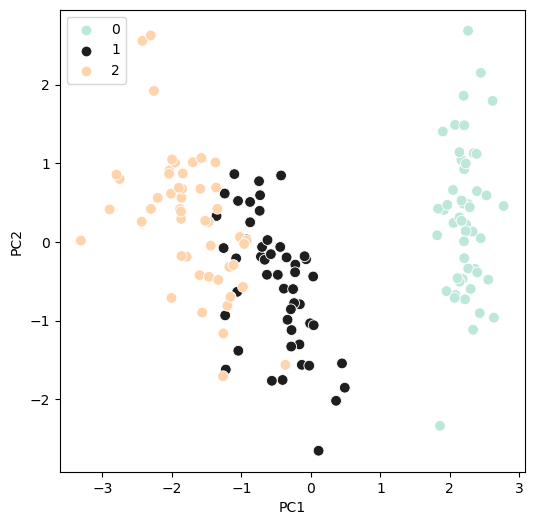

In [73]:
import seaborn as sb
import matplotlib.pyplot as plt
 
plt.figure(figsize = (6,6))
sb.scatterplot(data = principal_df , x = 'PC1',y = 'PC2' , hue = y , s = 60 , palette= 'icefire')
plt.show()


## 3. Loadingmatrix
* The loadings (or weights) are the correlation coefficients between the original features and the principal components.
* To get the loadings, we just need to access the attribute components_ pf PCA.

In [77]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [78]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=['SepalL', 'SepalW','PetalL','PetalW'])
loadings

,PC1,PC2
SepalL,0.521066,0.377418
SepalW,-0.269347,0.923296
PetalL,0.580413,0.024492
PetalW,0.564857,0.066942


* The columns of the dataframe contain the eigenvectors associated with the first two principal components. 
* Each element represents a loading, namely how much (the weight) each original variable contributes to the corresponding principal component.

In [20]:
def loading_plot(coeff, labels):
    n = coeff.shape[0]
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], head_width = 0.05, head_length = 0.05, color = '#21918C',alpha = 0.5)
        plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = '#21918C', ha = 'center', va = 'center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid()

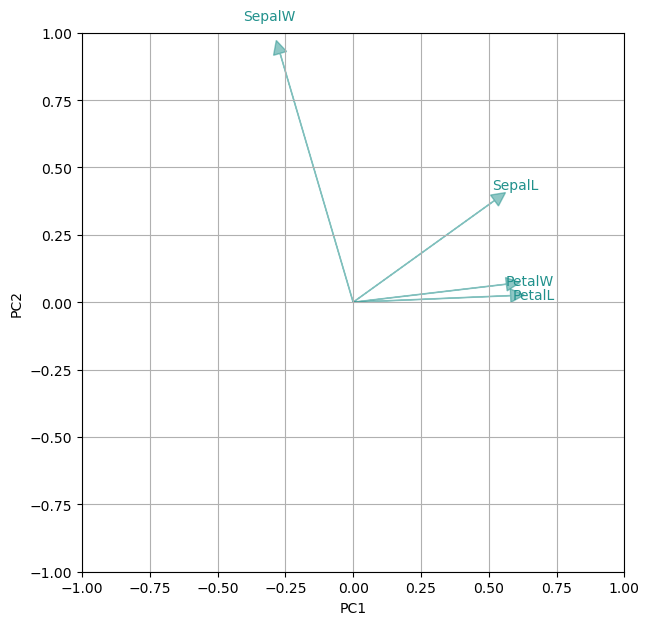

In [79]:
fig, ax = plt.subplots(figsize = (7,7))
loading_plot(pca.components_.T, ['SepalL', 'SepalW','PetalL','PetalW'])